# Import

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [34]:
drugs = pd.read_csv('drugs.csv')

 # Can medicines be grouped by patterns of missing regulatory data that reflect different approval eras or regulatory contexts?

Motivation from EDA: Missingness is structured rather than random, with consistent sparsity patterns across subsets of drugs.

Who Benefits: Regulatory agencies can see indications of systematic documentation gaps and assess how data completeness has evolved over time.


## Preprocessing

In [35]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

In [36]:
drugs['decision_date'] = pd.to_datetime(drugs['decision_date'], errors='coerce')
drugs['approval_year'] = drugs['decision_date'].dt.year
drugs_approved_per_year = drugs['approval_year'].value_counts().sort_index()
display(drugs_approved_per_year.tail(10))

,count
approval_year,
2014.0,31
2015.0,30
2016.0,33
2017.0,37
2018.0,54
2019.0,59
2020.0,100
2021.0,381
2022.0,794


In [37]:
drugs.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url,approval_year
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2022.0
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0


## Prepare Missingness Data

Create a new DataFrame that indicates the presence (0) or absence (1) of data for relevant regulatory columns in the `drugs` DataFrame. This will transform the dataset into a format suitable for clustering based on missingness patterns.


In [38]:
missing_cols = drugs.columns[drugs.isnull().any()].tolist()

missingness_df = drugs[missing_cols].isnull().astype(int)
display(missingness_df.head())
display(missingness_df.tail())

,therapeutic_area,common_name,active_substance,authorisation_status,atc_code,marketing_authorisation_date,date_of_refusal_of_marketing_authorisation,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,revision_date,approval_year
0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


,therapeutic_area,common_name,active_substance,authorisation_status,atc_code,marketing_authorisation_date,date_of_refusal_of_marketing_authorisation,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,revision_date,approval_year
1983,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1984,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1985,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1986,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1987,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0


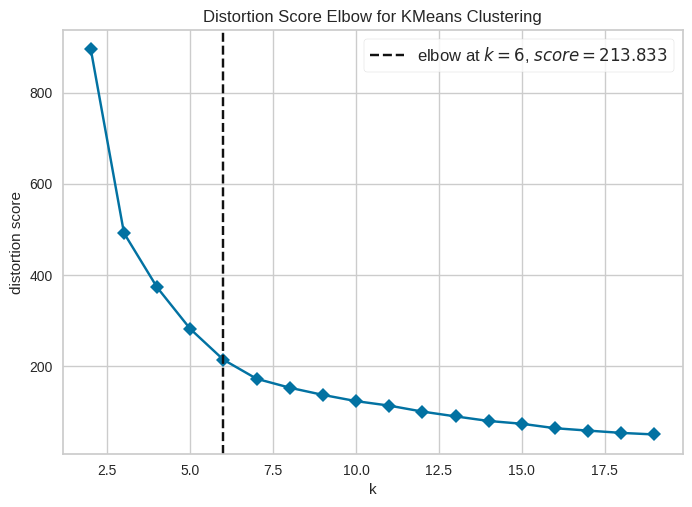

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [39]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='distortion', timings=False, random_state=42
)

visualizer.fit(missingness_df)
visualizer.show()

Association Rules

Hierarchical Clustering

Feature Normalization

## K-Means Clustering

K-Means on missingness data using the optimal number of clusters identified. Assign labels back to the original `drugs` DataFrame to group medicines by their missing data patterns.



Initialize a KMeans model with 3 clusters, fit it to the `missingness_df` to cluster medicines based on their missing data patterns, and then assign the resulting cluster labels to a new column in the original `drugs` DataFrame.



In [40]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
missingness_clusters = kmeans.fit_predict(missingness_df)
drugs['missingness_cluster'] = missingness_clusters
display(drugs.head())

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url,approval_year,missingness_cluster
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2022.0,2
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2


In [41]:
drugs['decision_date'] = pd.to_datetime(drugs['decision_date'], errors='coerce')
drugs['approval_year'] = drugs['decision_date'].dt.year

In [42]:
avg_approval_year_per_cluster = drugs.groupby('missingness_cluster')['approval_year'].mean()

missingness_df['missingness_cluster'] = drugs['missingness_cluster']
mean_missingness_per_cluster = missingness_df.groupby('missingness_cluster').mean()

print("\nAverage Approval Year per Cluster:")
print(avg_approval_year_per_cluster)

print("\nMean Missingness Percentage per Cluster for each Regulatory Column:")
print(mean_missingness_per_cluster)


Average Approval Year per Cluster:
missingness_cluster
0    2018.028346
1    2020.261905
2    2021.801811
3    2017.902098
4            NaN
5    2012.755556
Name: approval_year, dtype: float64

Mean Missingness Percentage per Cluster for each Regulatory Column:
                     therapeutic_area  common_name  active_substance  \
missingness_cluster                                                    
0                            0.001575     0.001575          0.000000   
1                            1.000000     0.007937          0.000000   
2                            0.003018     0.000000          0.000000   
3                            1.000000     0.006993          0.000000   
4                            0.244444     0.022222          0.022222   
5                            0.022222     0.000000          0.000000   

                     authorisation_status  atc_code  \
missingness_cluster                                   
0                                0.000000  0.00157

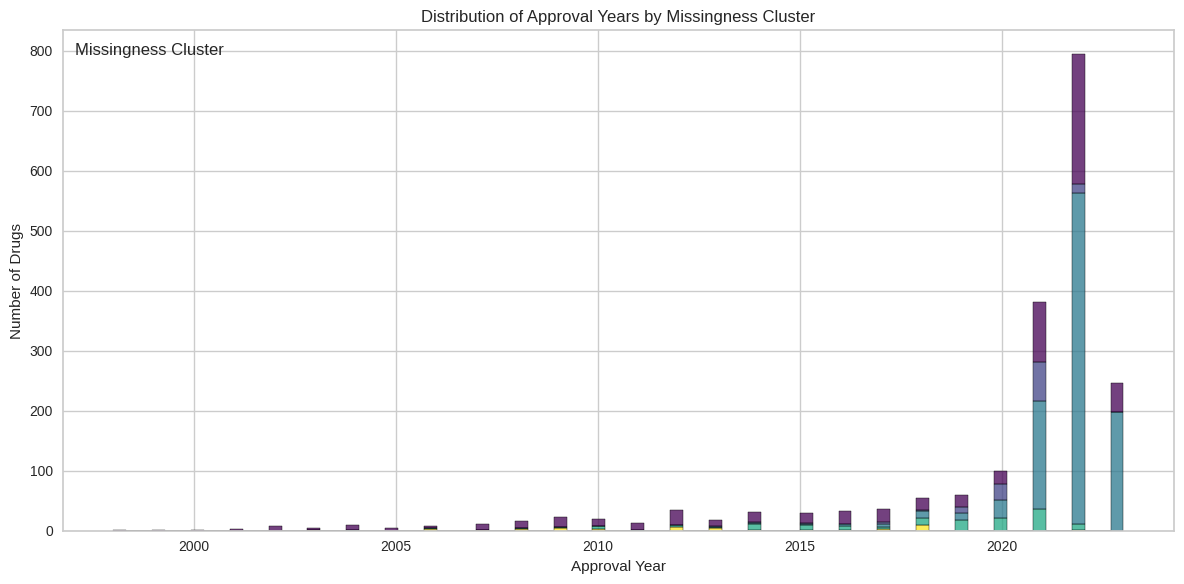

In [43]:
plt.figure(figsize=(12, 6))
sns.histplot(data=drugs, x='approval_year', hue='missingness_cluster', multiple='stack', palette='viridis', kde=False)
plt.title('Distribution of Approval Years by Missingness Cluster')
plt.xlabel('Approval Year')
plt.ylabel('Number of Drugs')
plt.legend(title='Missingness Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

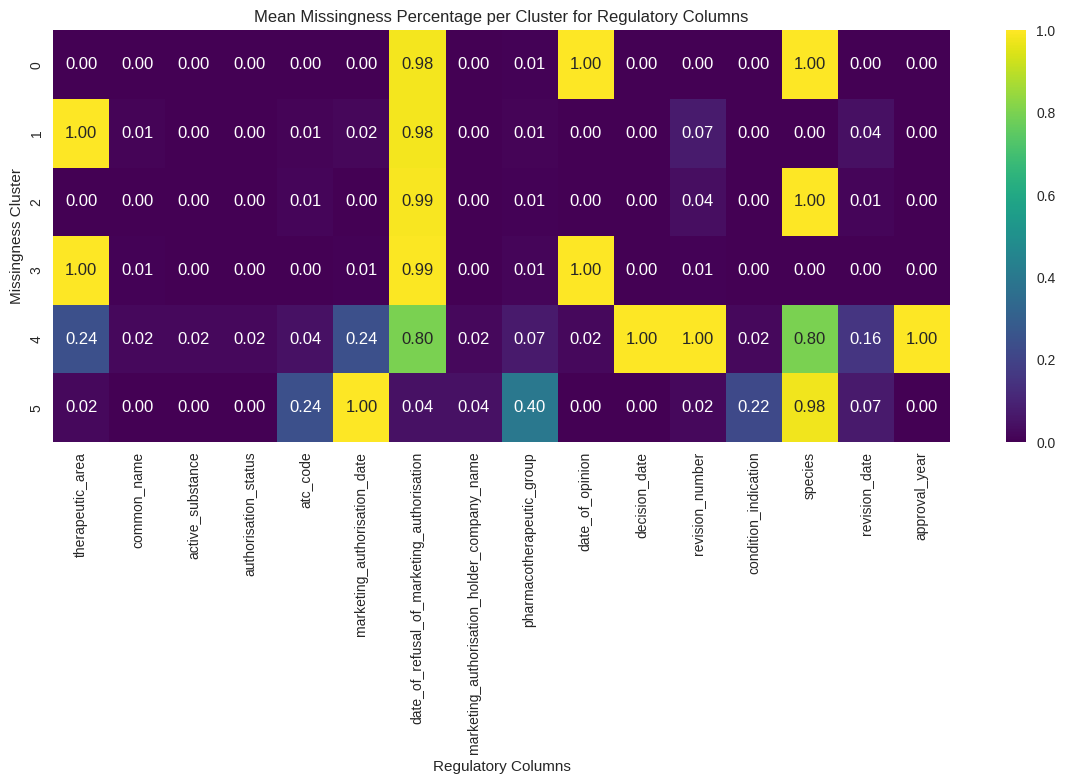

In [44]:
plt.figure(figsize=(12, 8))
sns.heatmap(mean_missingness_per_cluster, annot=True, cmap='viridis', fmt='.2f')
plt.title('Mean Missingness Percentage per Cluster for Regulatory Columns')
plt.xlabel('Regulatory Columns')
plt.ylabel('Missingness Cluster')
plt.tight_layout()
plt.show()